In [8]:
#==================================
# Import Libraries
#==================================

In [46]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
print("The libraries successfully")

The libraries successfully


In [10]:
#========================================
# Load Dataset
#========================================

In [11]:
# Load the CSV
df = pd.read_csv("/content/loan_prediction.csv")

In [12]:
# Display first roew
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
# Check dataset dimensions
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 614
Columns: 13


In [14]:
# Display column names
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [15]:
#====================================
# Understand the Dataset
#====================================

In [16]:
# Check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [17]:
# Statistical summary
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [18]:
# missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [19]:
# Duplicate rows
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [20]:
# Unique value
for col in df.columns:
  print("\n", col)
  print(df[col].unique())


 Loan_ID
['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP0012

In [21]:
#=====================================
# Data Cleaning
#=====================================

In [22]:
# Remove unnecessary column
df = df.drop("Loan_ID",axis=1)

In [23]:
# Clean Dependents
df["Dependents"] = df["Dependents"].replace("3+","3")

In [24]:
# Convert it to numeric
df["Dependents"] = pd.to_numeric(df["Dependents"],errors="coerce")

In [25]:
#============================================
# Exploratory Data Analysis
#============================================

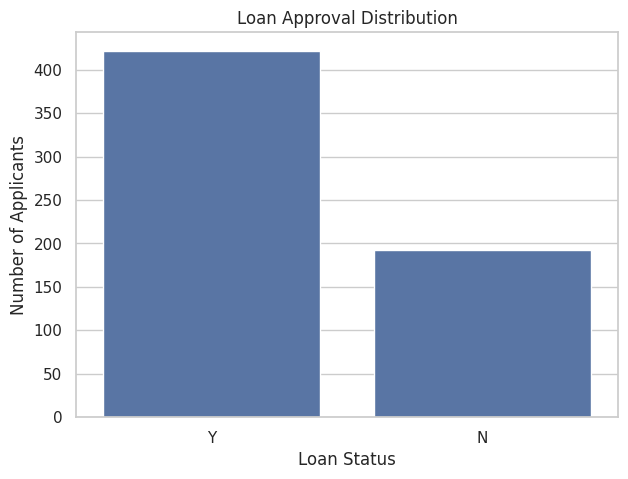

In [26]:
# Loan approval distribution
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Loan_Status"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

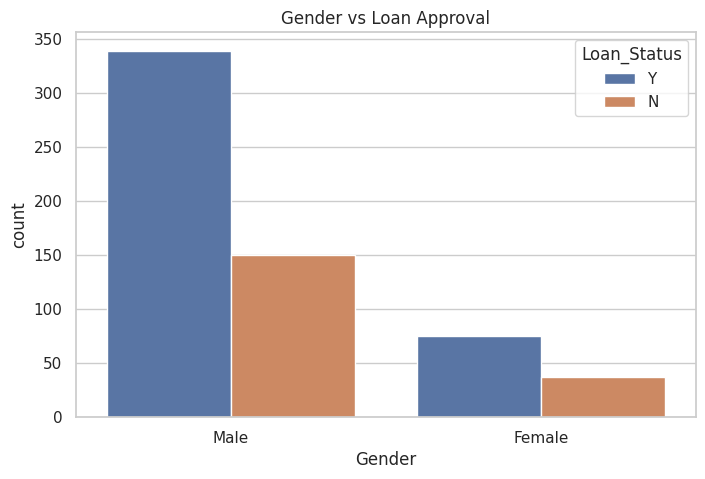

In [27]:
# Gender vs Loan Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Loan_Status"
)

plt.title("Gender vs Loan Approval")

plt.show()

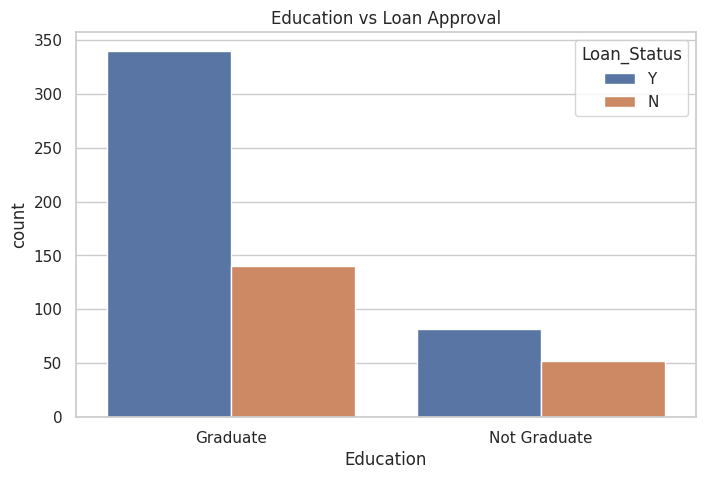

In [28]:
# Education vs Loan Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status"
)

plt.title("Education vs Loan Approval")

plt.show()

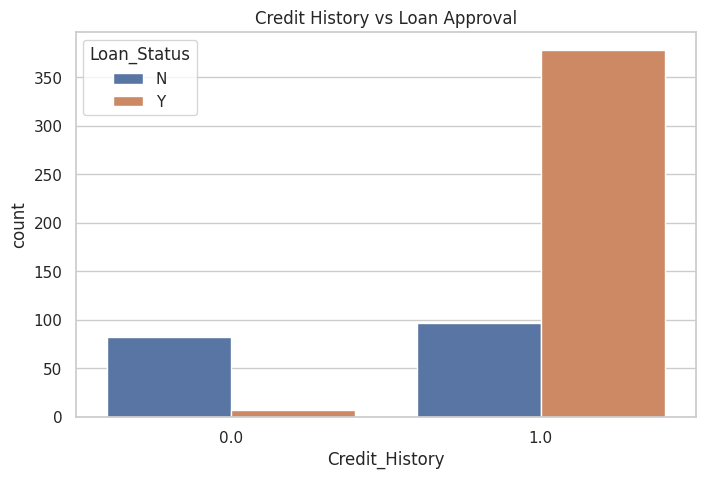

In [29]:
# Credit History vs Loan Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Approval")

plt.show()

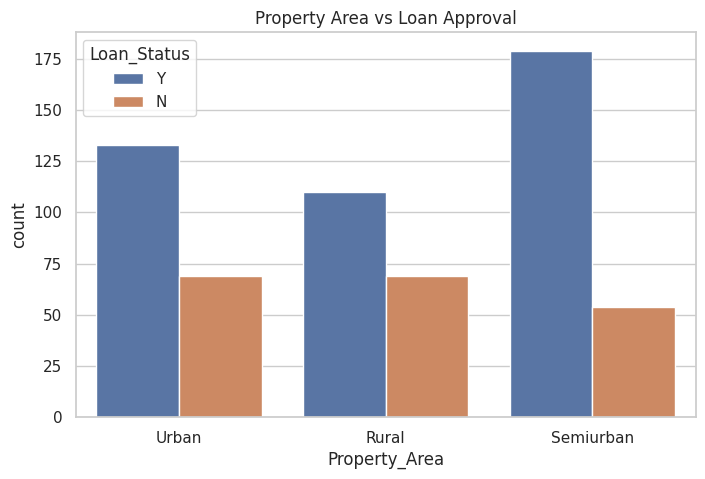

In [30]:
# Property Area vs Loan Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Property Area vs Loan Approval")

plt.show()

In [31]:
#==================================
# Feature Engineering
#==================================

In [32]:
# Total Income
df["TotalIncome"]=(
    df["ApplicantIncome"]+df["CoapplicantIncome"]
)

In [33]:
# Log-transfor income
df["TotalIncome_log"] = np.log(df["TotalIncome"])

In [34]:
# Log=transform LoanAmount
df["LoanAmount_log"] = np.log(df["LoanAmount"])


In [35]:
#========================================
# Separate Features and Target
#========================================

In [36]:
# Convert target
df["Loan_Status"] = df["Loan_Status"].map({"Y":1,"N":0})

In [38]:
# Create X and y
X = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]
print(X.shape)
print(y.shape)

(614, 14)
(614,)


In [ ]:
#=========================================
# Train-Test Split
#=========================================

In [39]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#======================================
# Preprocessing Pipeline
#======================================

In [40]:
# Numerical
numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Dependents",
    "TotalIncome",
    "TotalIncome_log",
    "LoanAmount_log"
]



In [41]:
# Categorical
categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area"
]


In [42]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [43]:
# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [44]:
# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


In [ ]:
#=======================================
# Handle Class Imbalance
#=======================================

In [45]:
print(y.value_counts())

print(
    y.value_counts(normalize=True) * 100
)

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    68.729642
0    31.270358
Name: proportion, dtype: float64


In [ ]:
#=====================================
# Train Algorithm 1
#=====================================

In [47]:
# Logistic Regression
logistic_model=ImbPipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(random_state=42)
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)
logistic_model.fit(
    X_train,
    y_train
)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Dependents', 'TotalIncome',
                                                   'TotalIncome_log',
                                                   'LoanAmount_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [49]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
#============================
# Train Algorithm 2
#============================

In [50]:
# Decision Tree
decision_tree_model = ImbPipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(random_state=42)
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Dependents', 'TotalIncome',
                                                   'TotalIncome_log',
                                                   'LoanAmount_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [51]:
y_pred_dt = decision_tree_model.predict(X_test)

y_prob_dt = decision_tree_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
#==============================
# Train Algorithm 3
#==============================

In [52]:
# Ramdom Forest
random_forest_model = ImbPipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "smote",
            SMOTE(random_state=42)
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                max_depth=8
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Dependents', 'TotalIncome',
                                                   'TotalIncome_log',
                                                   'LoanAmount_log']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_depth=8, n_estimators=300,
                                        random_state=42))])

In [53]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
#===============================
# Evaluate the Models
#===============================

In [54]:
def evaluate_model(
    name,
    y_true,
    y_pred,
    y_prob
):

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [55]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt,
        y_prob_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

In [56]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.821138,0.853933,0.894118,0.873563,0.869040
1,Decision Tree,0.756098,0.857143,0.776471,0.814815,0.798916
2,Random Forest,0.804878,0.842697,0.882353,0.862069,0.823220


In [57]:
#================================
# Model Comparison Visualization
#================================

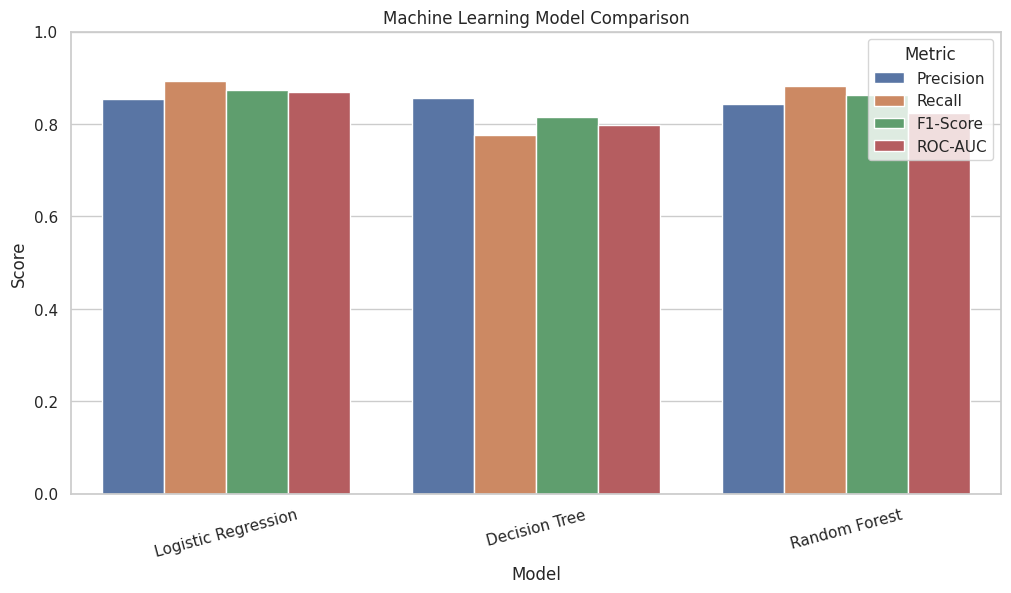

In [58]:
plt.figure(figsize=(12,6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Machine Learning Model Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [ ]:
#==========================
# Confusion Matrix
#==========================

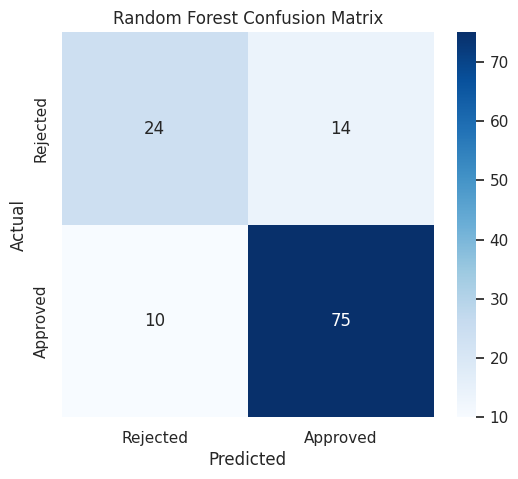

In [59]:
# Random Forest
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Rejected",
        "Approved"
    ],
    yticklabels=[
        "Rejected",
        "Approved"
    ]
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
#===========================
# ROC Curve
#===========================

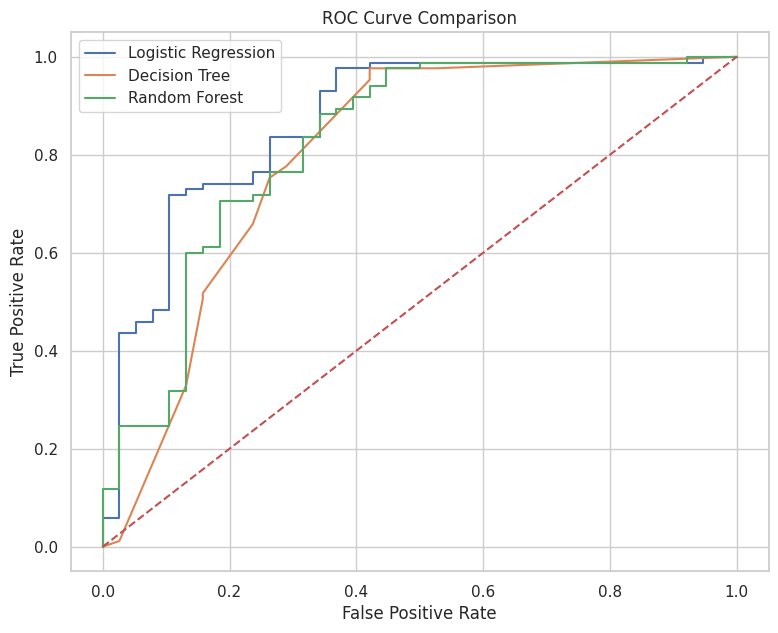

In [61]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(9,7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label="Decision Tree"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [ ]:
#==============================
# Classification Reports
#==============================

In [62]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

print("\nDECISION TREE")
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

print("\nRANDOM FOREST")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.74      0.66      0.69        38
           1       0.85      0.89      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.78       123
weighted avg       0.82      0.82      0.82       123


DECISION TREE
              precision    recall  f1-score   support

           0       0.59      0.71      0.64        38
           1       0.86      0.78      0.81        85

    accuracy                           0.76       123
   macro avg       0.72      0.74      0.73       123
weighted avg       0.77      0.76      0.76       123


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80 

In [ ]:
#====================================
# Feature Importance
#====================================

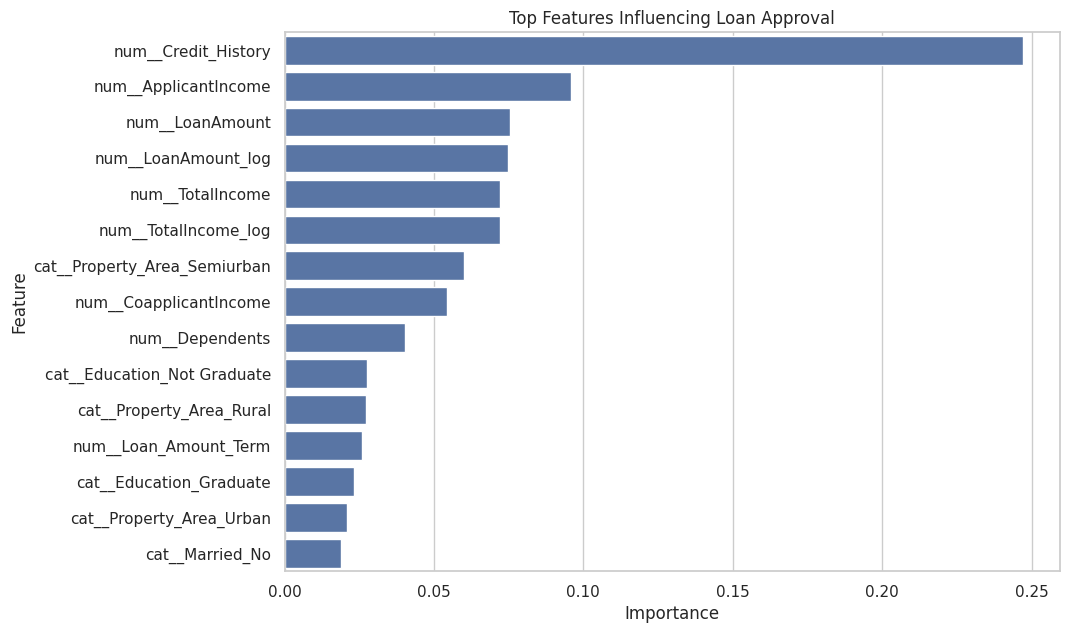

In [64]:
rf_model = random_forest_model.named_steps["model"]

feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).head(15)

importance



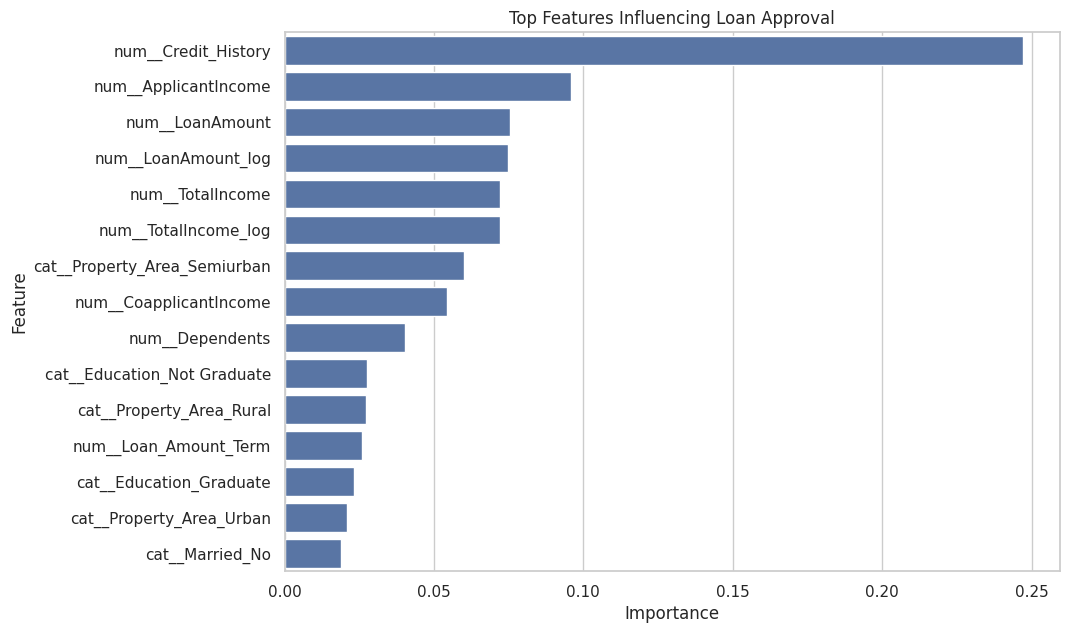

In [65]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Influencing Loan Approval"
)

plt.show()

In [66]:
#==================================
# Threshold Optimization
#==================================

In [67]:
thresholds = np.arange(
    0.30,
    0.71,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_rf >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.30,0.792453,0.988235,0.879581
1,0.35,0.813725,0.976471,0.887701
2,0.40,0.828283,0.964706,0.891304
3,0.45,0.838710,0.917647,0.876404
4,0.50,0.842697,0.882353,0.862069
5,0.55,0.845238,0.835294,0.840237
6,0.60,0.866667,0.764706,0.812500
7,0.65,0.881356,0.611765,0.722222
8,0.70,0.897959,0.517647,0.656716


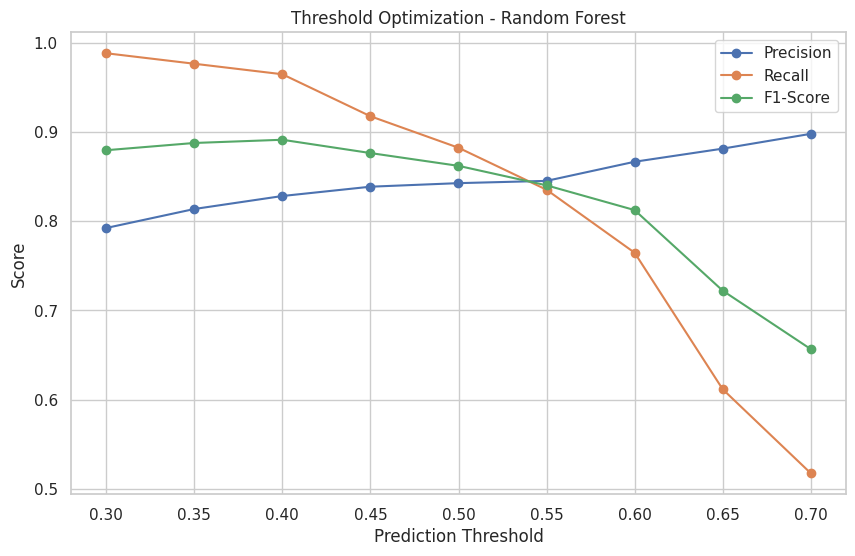

In [68]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Optimization - Random Forest"
)

plt.legend()

plt.show()

In [72]:
recommended_threshold = 0.40
# Check that the model exists
print(logistic_model)
print("Recommended threshold:", recommended_threshold)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Dependents', 'TotalIncome',
                                                   'TotalIncome_log',
                                                   'LoanAmount_log']

In [75]:
#========================================
# Create the Input Function
#========================================
recommended_threshold = 0.40
def predict_loan():

    print("=" * 50)
    print("       LOAN APPROVAL PREDICTION")
    print("=" * 50)

    # Get user input
    Namr = input("Name: ")
    Gender = input("Gender (Male/Female): ")
    Married = input("Married (Yes/No): ")
    Dependents = input("Dependents (0/1/2/3): ")
    Education = input("Education (Graduate/Not Graduate): ")
    Self_Employed = input("Self Employed (Yes/No): ")

    ApplicantIncome = float(
        input("Applicant Income: ")
    )

    CoapplicantIncome = float(
        input("Coapplicant Income: ")
    )

    LoanAmount = float(
        input("Loan Amount: ")
    )

    Loan_Amount_Term = float(
        input("Loan Amount Term: ")
    )

    Credit_History = float(
        input("Credit History (1 = Good, 0 = Bad): ")
    )

    Property_Area = input(
        "Property Area (Urban/Semiurban/Rural): "
    )


    # Create input DataFrame
    input_data = pd.DataFrame({
        "Gender": [Gender],
        "Married": [Married],
        "Dependents": [Dependents],
        "Education": [Education],
        "Self_Employed": [Self_Employed],
        "ApplicantIncome": [ApplicantIncome],
        "CoapplicantIncome": [CoapplicantIncome],
        "LoanAmount": [LoanAmount],
        "Loan_Amount_Term": [Loan_Amount_Term],
        "Credit_History": [Credit_History],
        "Property_Area": [Property_Area]
    })


    # Feature engineering
    input_data["Dependents"] = pd.to_numeric(
        input_data["Dependents"],
        errors="coerce"
    )

    input_data["TotalIncome"] = (
        input_data["ApplicantIncome"] +
        input_data["CoapplicantIncome"]
    )

    input_data["TotalIncome_log"] = np.log1p(
        input_data["TotalIncome"]
    )

    input_data["LoanAmount_log"] = np.log1p(
        input_data["LoanAmount"]
    )


    # Prediction probability
    probability = logistic_model.predict_proba(
        input_data
    )[0][1]


    # Use recommended threshold
    prediction = (
        probability >= recommended_threshold
    )


    print("\n" + "=" * 50)

    print(
        f"Approval Probability: {probability * 100:.2f}%"
    )

    print(
        f"Decision Threshold: "
        f"{recommended_threshold:.2f}"
    )

    if prediction:
        print("🟢 LOAN APPROVED")
    else:
        print("🔴 LOAN REJECTED")

    print("=" * 50)

In [76]:
predict_loan()

       LOAN APPROVAL PREDICTION
Name: Teja
Gender (Male/Female): Male
Married (Yes/No): No
Dependents (0/1/2/3): 0
Education (Graduate/Not Graduate): Graduate
Self Employed (Yes/No): Yes
Applicant Income: 10000
Coapplicant Income: 2500
Loan Amount: 250
Loan Amount Term: 400
Credit History (1 = Good, 0 = Bad): 1
Property Area (Urban/Semiurban/Rural): Urban

Approval Probability: 45.40%
Decision Threshold: 0.40
🟢 LOAN APPROVED
